# ORCESTRA Campaign: Kinematic Profiling of Tropical Convection
**Dataset:** Level-4 HALO Aircraft Dropsonde Circle Products (EC-TOOC / ORCESTRA)  
**Objective:** To categorize mesoscale vertical velocity ($\omega$) profiles.

### Scientific Framework
Following Johnson et al. (1999) and Back & Bretherton (2006), the flight circles are classified based on the magnitude and pressure level of maximum macroscopic ascent (minimum $\omega$):
* **Suppressed / Weak:** No significant ascent (minimum $\omega > -0.05$ Pa/s).
* **Top-Heavy (Deep):** Peak ascent occurs above the freezing level (**500 hPa**).
* **Bottom-Heavy (Congestus):** Peak ascent occurs between **800 hPa** and **500 hPa**.
* **Shallow:** Peak ascent is trapped below the trade inversion (**800 hPa**).

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import os

# Load your ORCESTRA Level-4 dataset
# (Replace the path below with the actual location of your data file)
# 1. SETUP & LOAD DATA
os.environ["IPFS_GATEWAY"] = "https://ipfs.io"
data_url = "ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i"
print(f"Attempting to access data from: {data_url}")

try:
    ds = xr.open_dataset(data_url, engine="zarr")
    print("Dataset successfully loaded!\n")
except Exception as e:
    print(f"Error loading dataset: {e}")

Attempting to access data from: ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i
Dataset successfully loaded!



### Step 1: Categorization Algorithm
This algorithm loops through every individual flight circle. It finds the strongest upward motion (the minimum $\omega$ value) and checks the pressure level (`p_mean`) where it occurs to assign the correct convective regime.

In [2]:
# Create an empty list to store the category for each circle
categories = []

for c in ds.circle.values:
    # Extract the vertical velocity and pressure profiles for this specific circle
    omega_profile = ds['omega'].sel(circle=c)
    p_profile = ds['p_mean'].sel(circle=c) / 100 # Convert Pa to hPa
    
    # Handle circles with missing data
    if np.isnan(omega_profile).all():
        categories.append("Missing Data")
        continue
        
    # Find the strongest upward motion (minimum omega)
    min_omega = omega_profile.min().values
    
    # Apply Criterion 1: Intensity
    if min_omega > -0.05:
        categories.append("Suppressed / Weak")
    else:
        # Apply Criterion 2: Altitude/Pressure of peak ascent
        idx_min = omega_profile.argmin().values
        p_peak = p_profile.isel(altitude=idx_min).values
        
        if p_peak < 500:
            categories.append("Top-Heavy (Deep)")
        elif p_peak < 800:
            categories.append("Bottom-Heavy (Congestus)")
        else:
            categories.append("Shallow")

# Add the categories back into the dataset as a new variable
ds['category'] = (('circle'), categories)

# We rename it to ds_categorized to match the rest of our plotting code
ds_categorized = ds

print("Categorization complete. Breakdown of regimes:")
print(pd.Series(categories).value_counts())

/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will chan

Categorization complete. Breakdown of regimes:
Top-Heavy (Deep)            29
Suppressed / Weak           22
Bottom-Heavy (Congestus)    22
Shallow                     14
Missing Data                 2
Name: count, dtype: int64


/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


### Step 2: Visualization of Vertical Profiles
For each identified regime, we generate two visualizations:
1. **Spaghetti Plot:** Overlays all profiles within a category alongside the ensemble mean.
2. **Individual Grid:** Displays each profile separately, labeled with its exact flight time (UTC) to highlight that multiple distinct atmospheric states are often sampled within a single day.


GENERATING PLOTS FOR REGIME: BOTTOM-HEAVY (CONGESTUS) (22 circles)



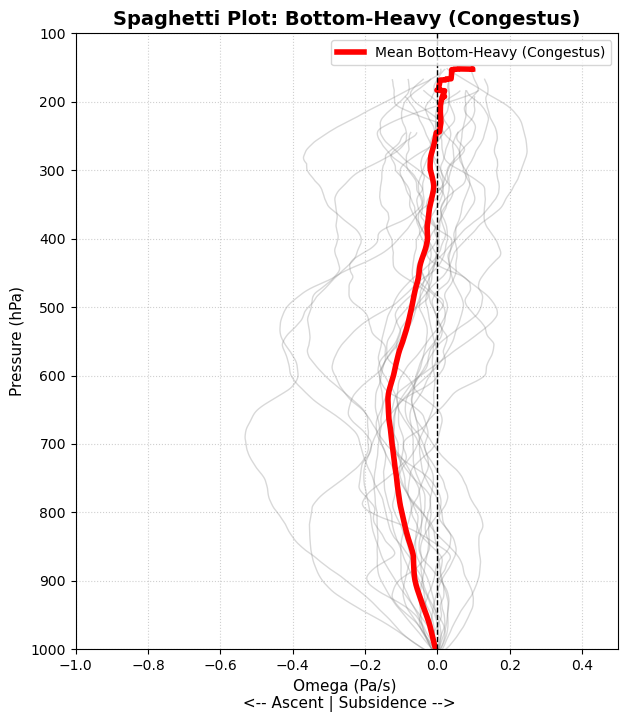

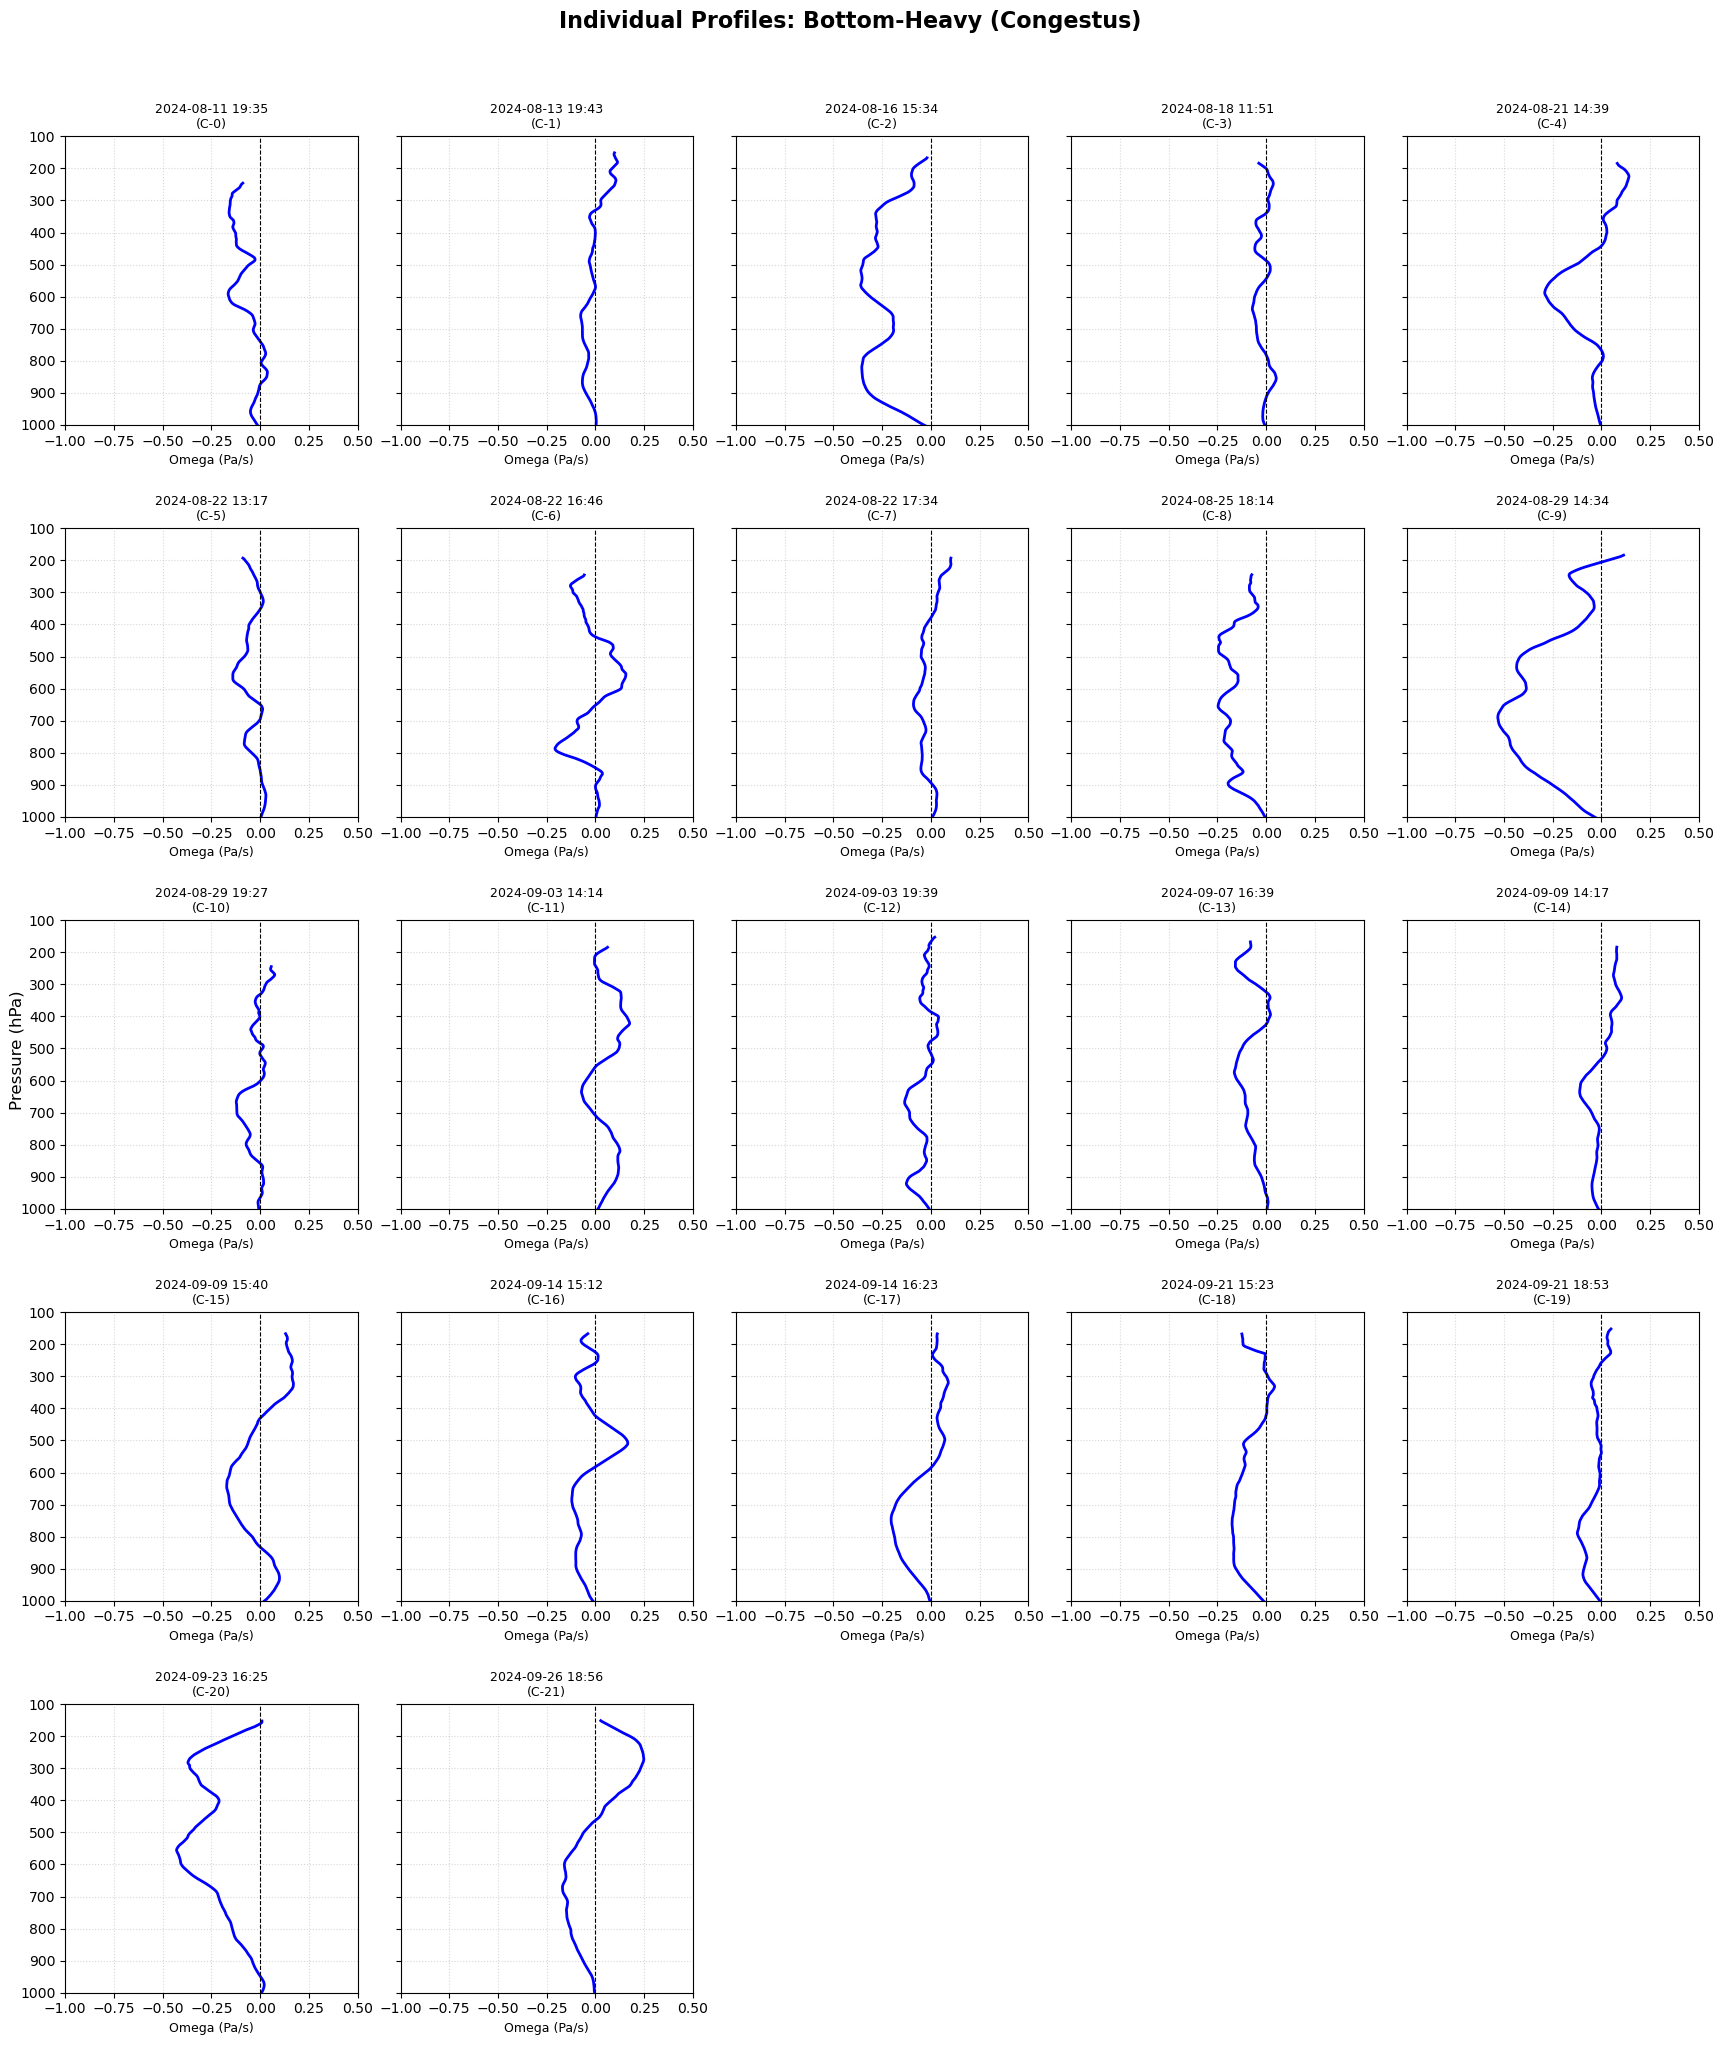


GENERATING PLOTS FOR REGIME: SHALLOW (14 circles)



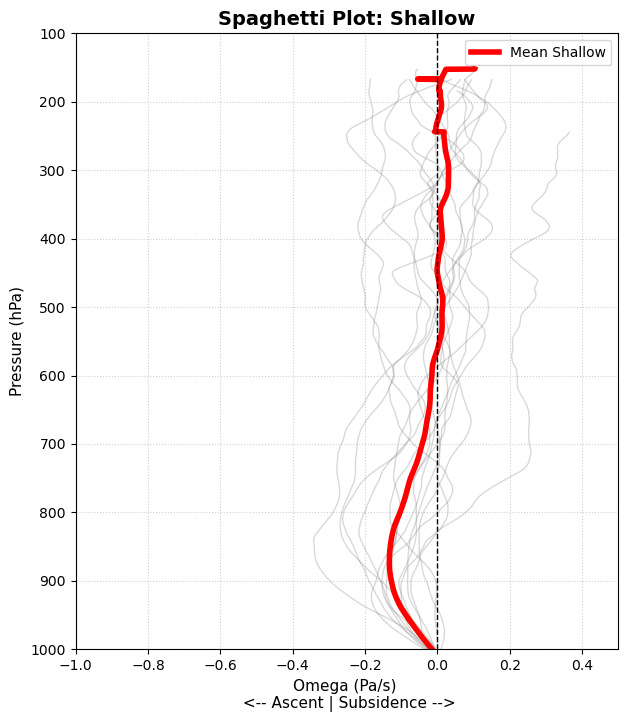

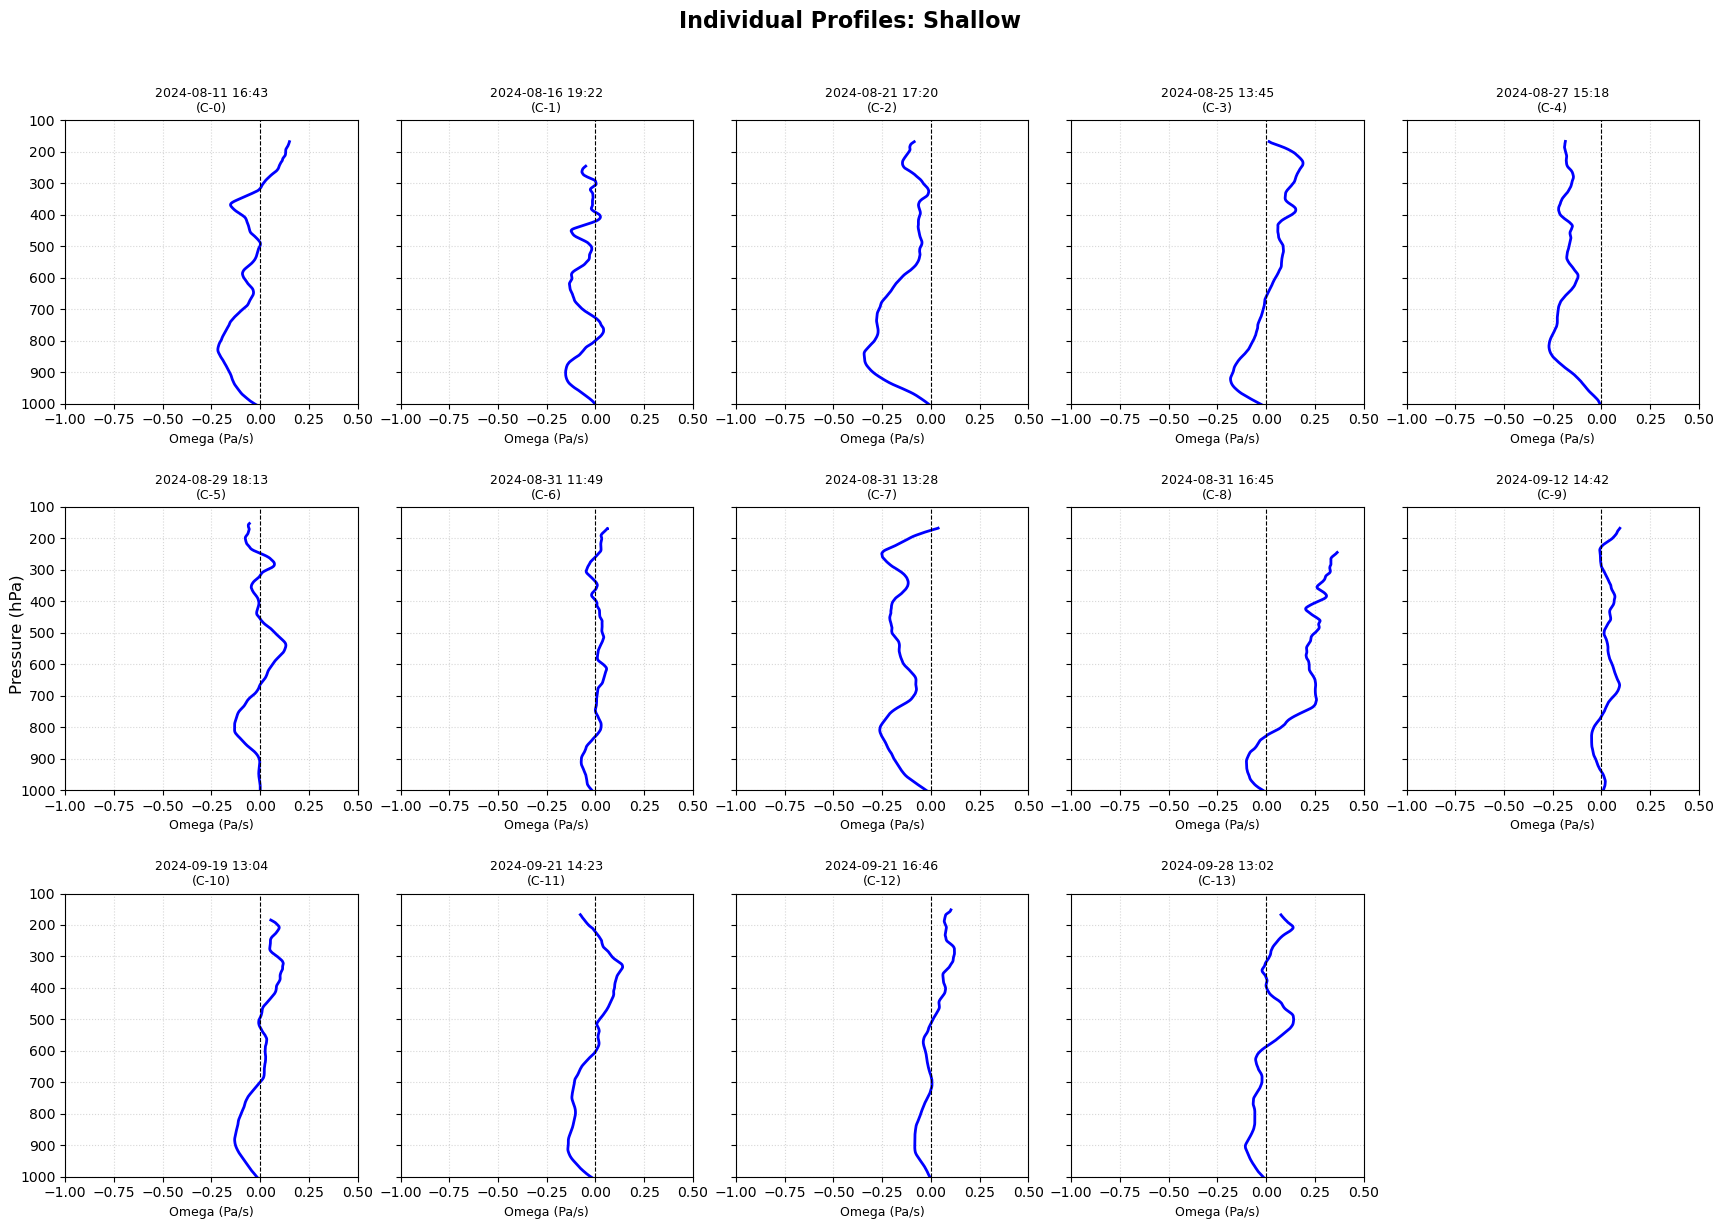


GENERATING PLOTS FOR REGIME: SUPPRESSED / WEAK (22 circles)



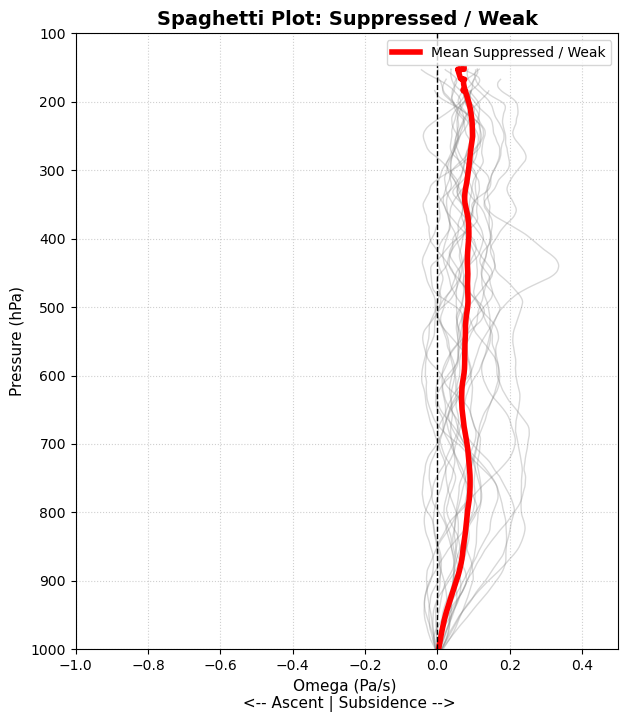

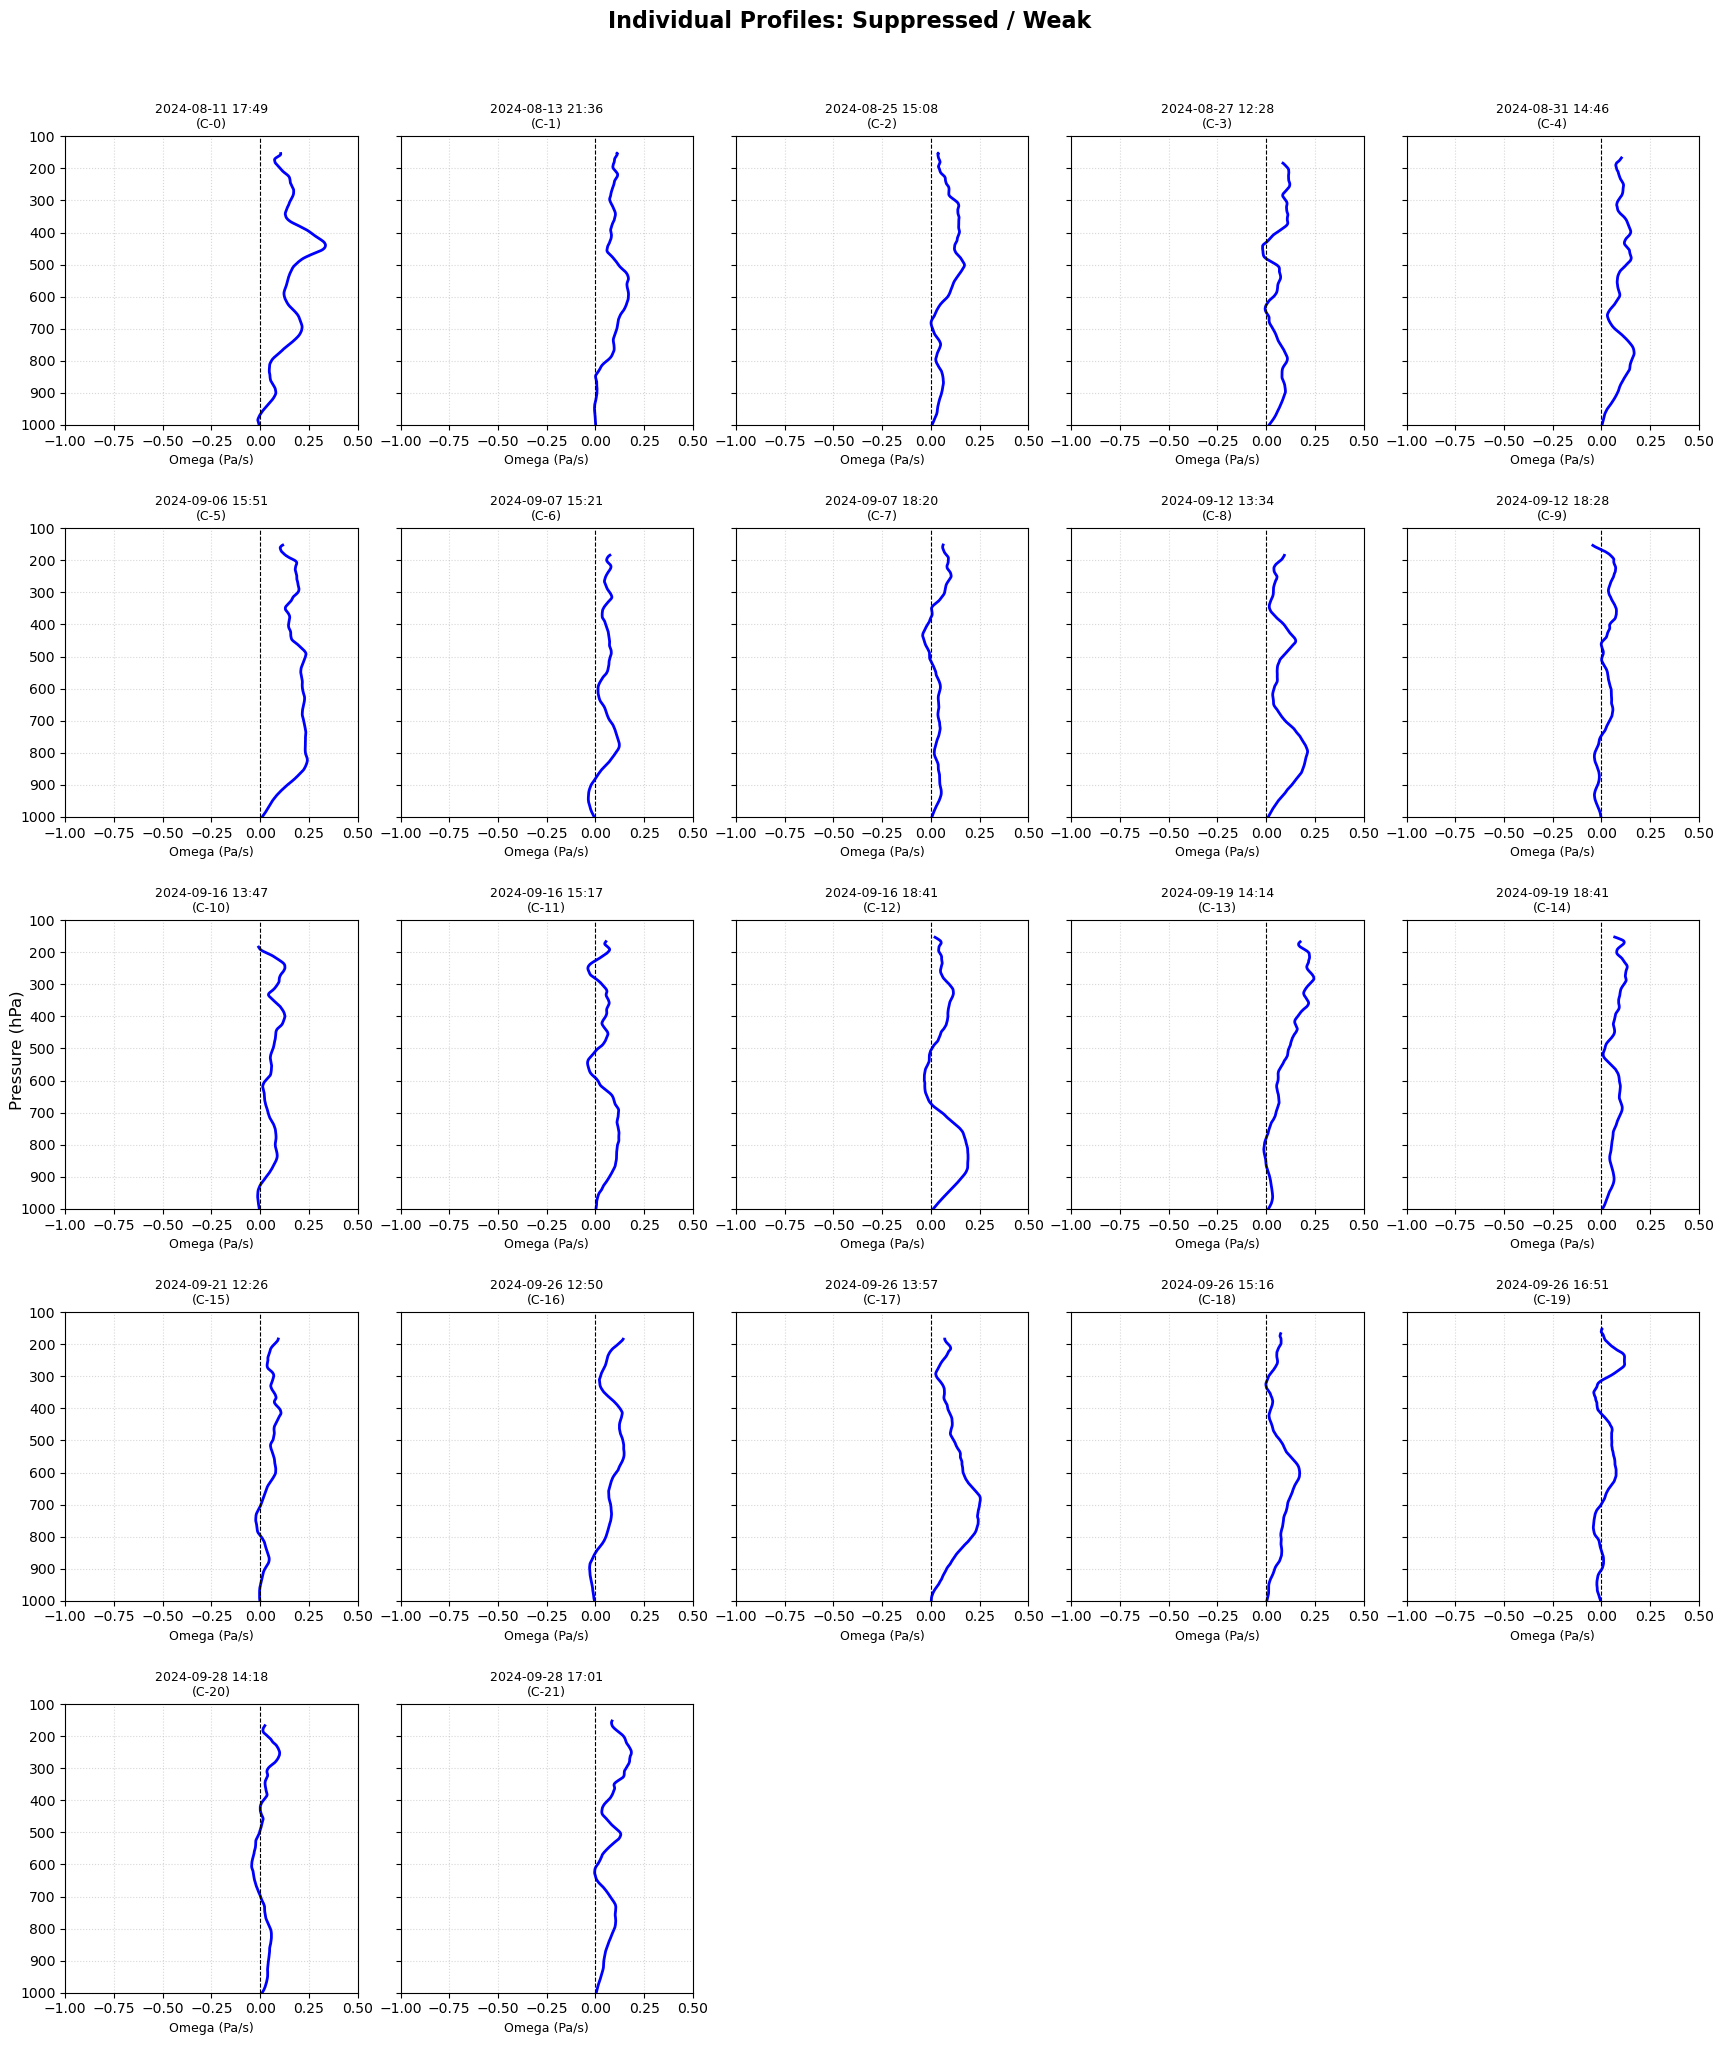


GENERATING PLOTS FOR REGIME: TOP-HEAVY (DEEP) (29 circles)



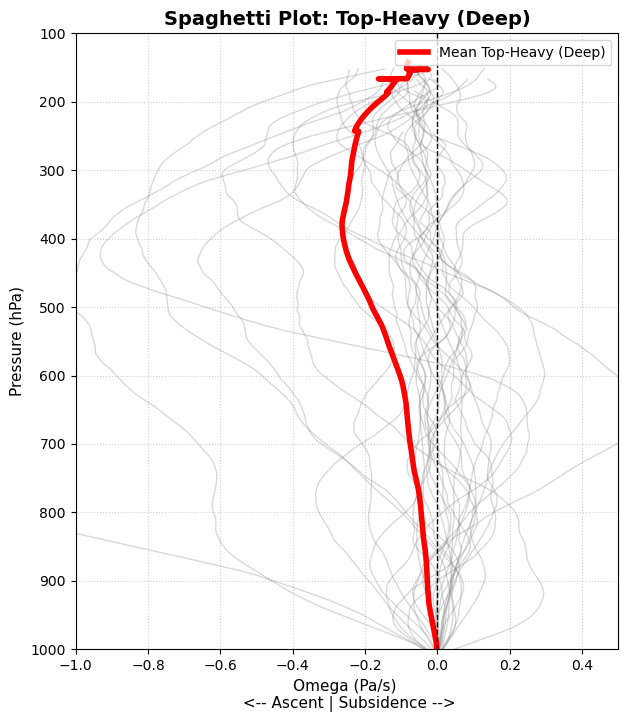

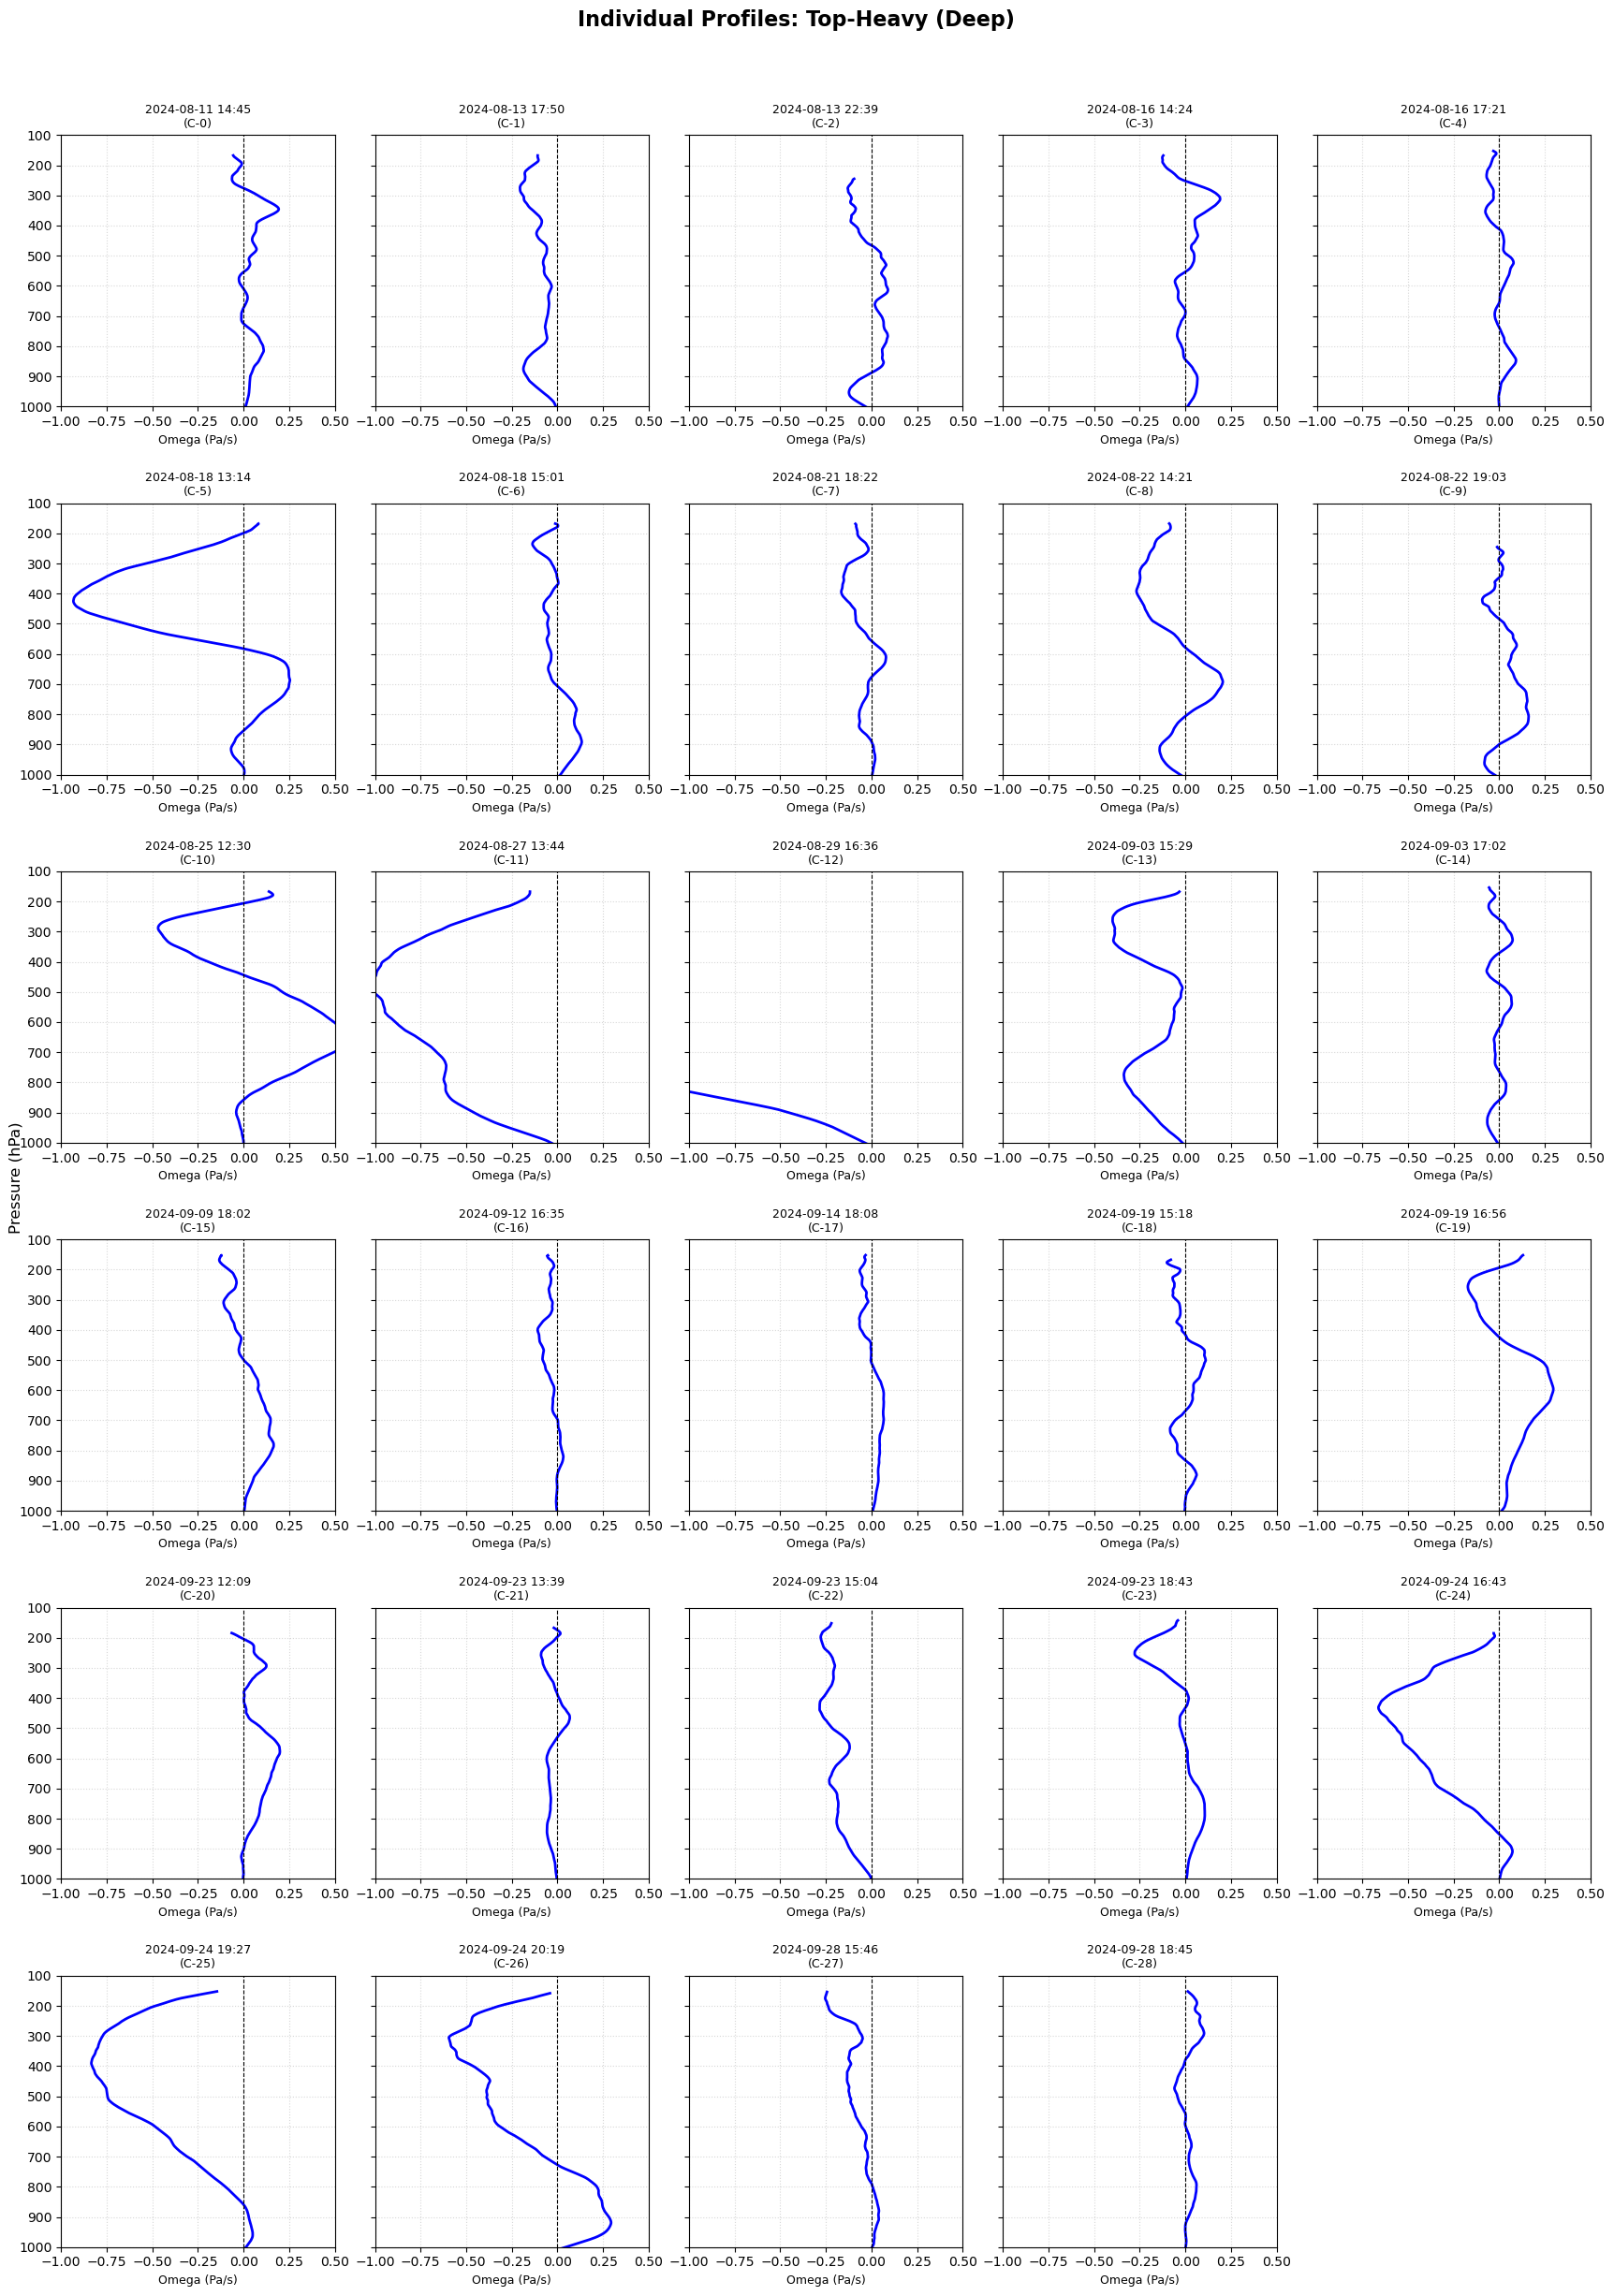

In [3]:
# Get a list of unique categories, skipping "Missing Data"
valid_categories = [cat for cat in np.unique(ds_categorized.category.values) if cat != "Missing Data"]

# Define consistent axes limits for fair comparison
x_limits = (-1.0, 0.5)
y_limits = (1000, 100) # Pressure in hPa. Matplotlib will automatically invert this!

# Loop through each category
for cat in valid_categories:
    
    # Filter data for this specific category
    cat_mask = ds_categorized.category == cat
    ds_cat = ds_categorized.isel(circle=cat_mask)
    
    circle_indices = ds_cat.circle.values
    n_circles = len(circle_indices)
    
    print(f"\n{'='*60}")
    print(f"GENERATING PLOTS FOR REGIME: {cat.upper()} ({n_circles} circles)")
    print(f"{'='*60}\n")
    
    # ---------------------------------------------------------
    # PLOT TYPE 1: THE "SPAGHETTI" PLOT
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(7, 8))
    
    for c in circle_indices:
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100 # Convert Pa to hPa
        ax1.plot(profile, pressure, color='gray', alpha=0.3, linewidth=1)
        
    mean_profile = ds_cat['omega'].mean(dim='circle')
    mean_pressure = ds_cat['p_mean'].mean(dim='circle') / 100
    
    ax1.plot(mean_profile, mean_pressure, color='red', linewidth=4, label=f'Mean {cat}')
    
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlim(x_limits)
    ax1.set_ylim(y_limits) 
    
    ax1.set_xlabel('Omega (Pa/s) \n <-- Ascent | Subsidence -->', fontsize=11)
    ax1.set_ylabel('Pressure (hPa)', fontsize=11)
    ax1.set_title(f'Spaghetti Plot: {cat}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()
    
    # ---------------------------------------------------------
    # PLOT TYPE 2: THE INDIVIDUAL GRID PLOTS
    # ---------------------------------------------------------
    cols = 5
    rows = math.ceil(n_circles / cols)
    
    fig2, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*4), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, c in enumerate(circle_indices):
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100
        
        # Extract Exact Date and Time
        raw_time = ds_cat['circle_time'].sel(circle=c).values
        datetime_str = pd.Timestamp(raw_time).strftime('%Y-%m-%d %H:%M')
        
        axes[i].plot(profile, pressure, color='blue', linewidth=2)
        axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)
        
        axes[i].set_title(f'{datetime_str}\n(C-{c})', fontsize=9) 
        axes[i].grid(True, linestyle=':', alpha=0.5)
        
        # Force X-labels to appear on every single chart in the grid
        axes[i].tick_params(labelbottom=True) 
        axes[i].set_xlabel('Omega (Pa/s)', fontsize=9)
        
    # Hide any extra empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    axes[0].set_xlim(x_limits)
    axes[0].set_ylim(y_limits)
    
    fig2.suptitle(f'Individual Profiles: {cat}', fontsize=16, fontweight='bold', y=1.02)
    fig2.supylabel('Pressure (hPa)', fontsize=12)
    
    plt.tight_layout(h_pad=2.0)
    plt.show()

### Step 3: Chronological Evolution of Convective Regimes
To map the temporal passage of synoptic-scale weather systems (such as African Easterly Waves), the categorized regimes are plotted chronologically. This visualizes periods of active, deep convection versus suppressed, dry conditions during the HALO flight missions.

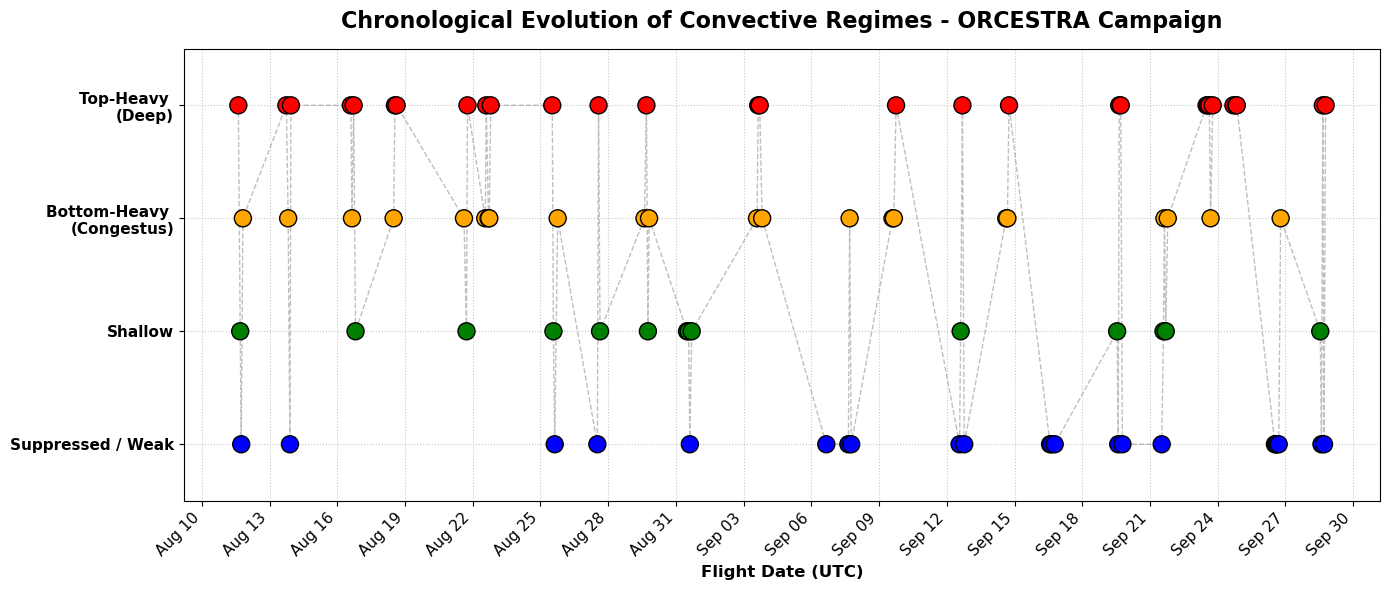

In [4]:
# 1. SETUP DATA FOR TIME SERIES
plot_times = []
plot_levels = []
plot_colors = []

# Define the Y-axis levels (intensity) and plotting colors
regime_mapping = {
    'Top-Heavy (Deep)': {'level': 4, 'color': 'red'},
    'Bottom-Heavy (Congestus)': {'level': 3, 'color': 'orange'},
    'Shallow': {'level': 2, 'color': 'green'},
    'Suppressed / Weak': {'level': 1, 'color': 'blue'}
}

# Extract time and category for each valid circle
for c in ds_categorized.circle.values:
    cat = str(ds_categorized.category.sel(circle=c).values)
    
    if cat == "Missing Data":
        continue
        
    raw_time = ds_categorized['circle_time'].sel(circle=c).values
    dt = pd.to_datetime(raw_time)
    
    plot_times.append(dt)
    plot_levels.append(regime_mapping[cat]['level'])
    plot_colors.append(regime_mapping[cat]['color'])

# 2. CREATE THE TIME SERIES PLOT
fig, ax = plt.subplots(figsize=(14, 6))

# Plot scatter points and chronological connecting line
scatter = ax.scatter(plot_times, plot_levels, c=plot_colors, s=150, edgecolors='black', linewidths=1, zorder=3)
ax.plot(plot_times, plot_levels, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=2)

# 3. FORMATTING THE Y-AXIS (Categories)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels([
    'Suppressed / Weak', 
    'Shallow', 
    'Bottom-Heavy \n(Congestus)', 
    'Top-Heavy \n(Deep)'
], fontsize=11, fontweight='bold')

# 4. FORMATTING THE X-AXIS (Dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3)) 
plt.xticks(rotation=45, ha='right', fontsize=11)

# General formatting
ax.set_title('Chronological Evolution of Convective Regimes - ORCESTRA Campaign', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Flight Date (UTC)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.7, zorder=1)
ax.set_ylim(0.5, 4.5)

plt.tight_layout()
plt.show()

### Spatial Distribution of Convective Regimes
To understand the geographic distribution of our data, we plot the physical locations of the HALO flight circles over the tropical Atlantic Ocean. 
First, we generate a master map combining all flight days, color-coded by convective regime. Then, we generate individual daily maps to track the aircraft's specific sampling path for each date.

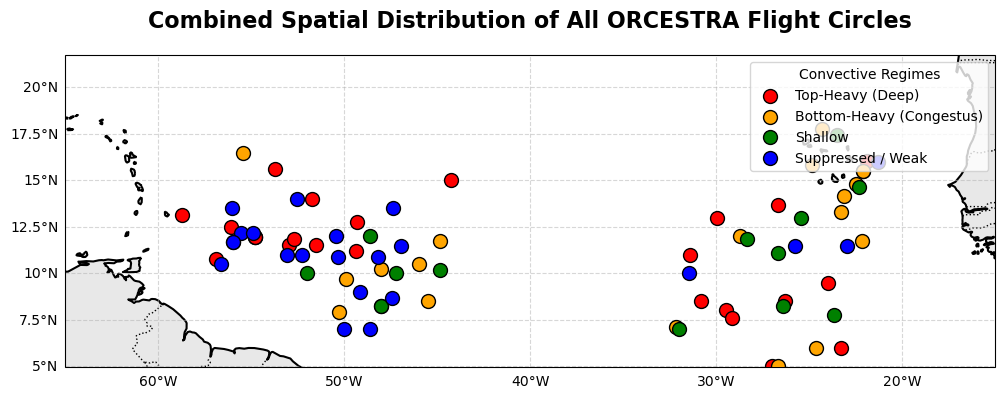


GENERATING INDIVIDUAL DAILY FLIGHT MAPS



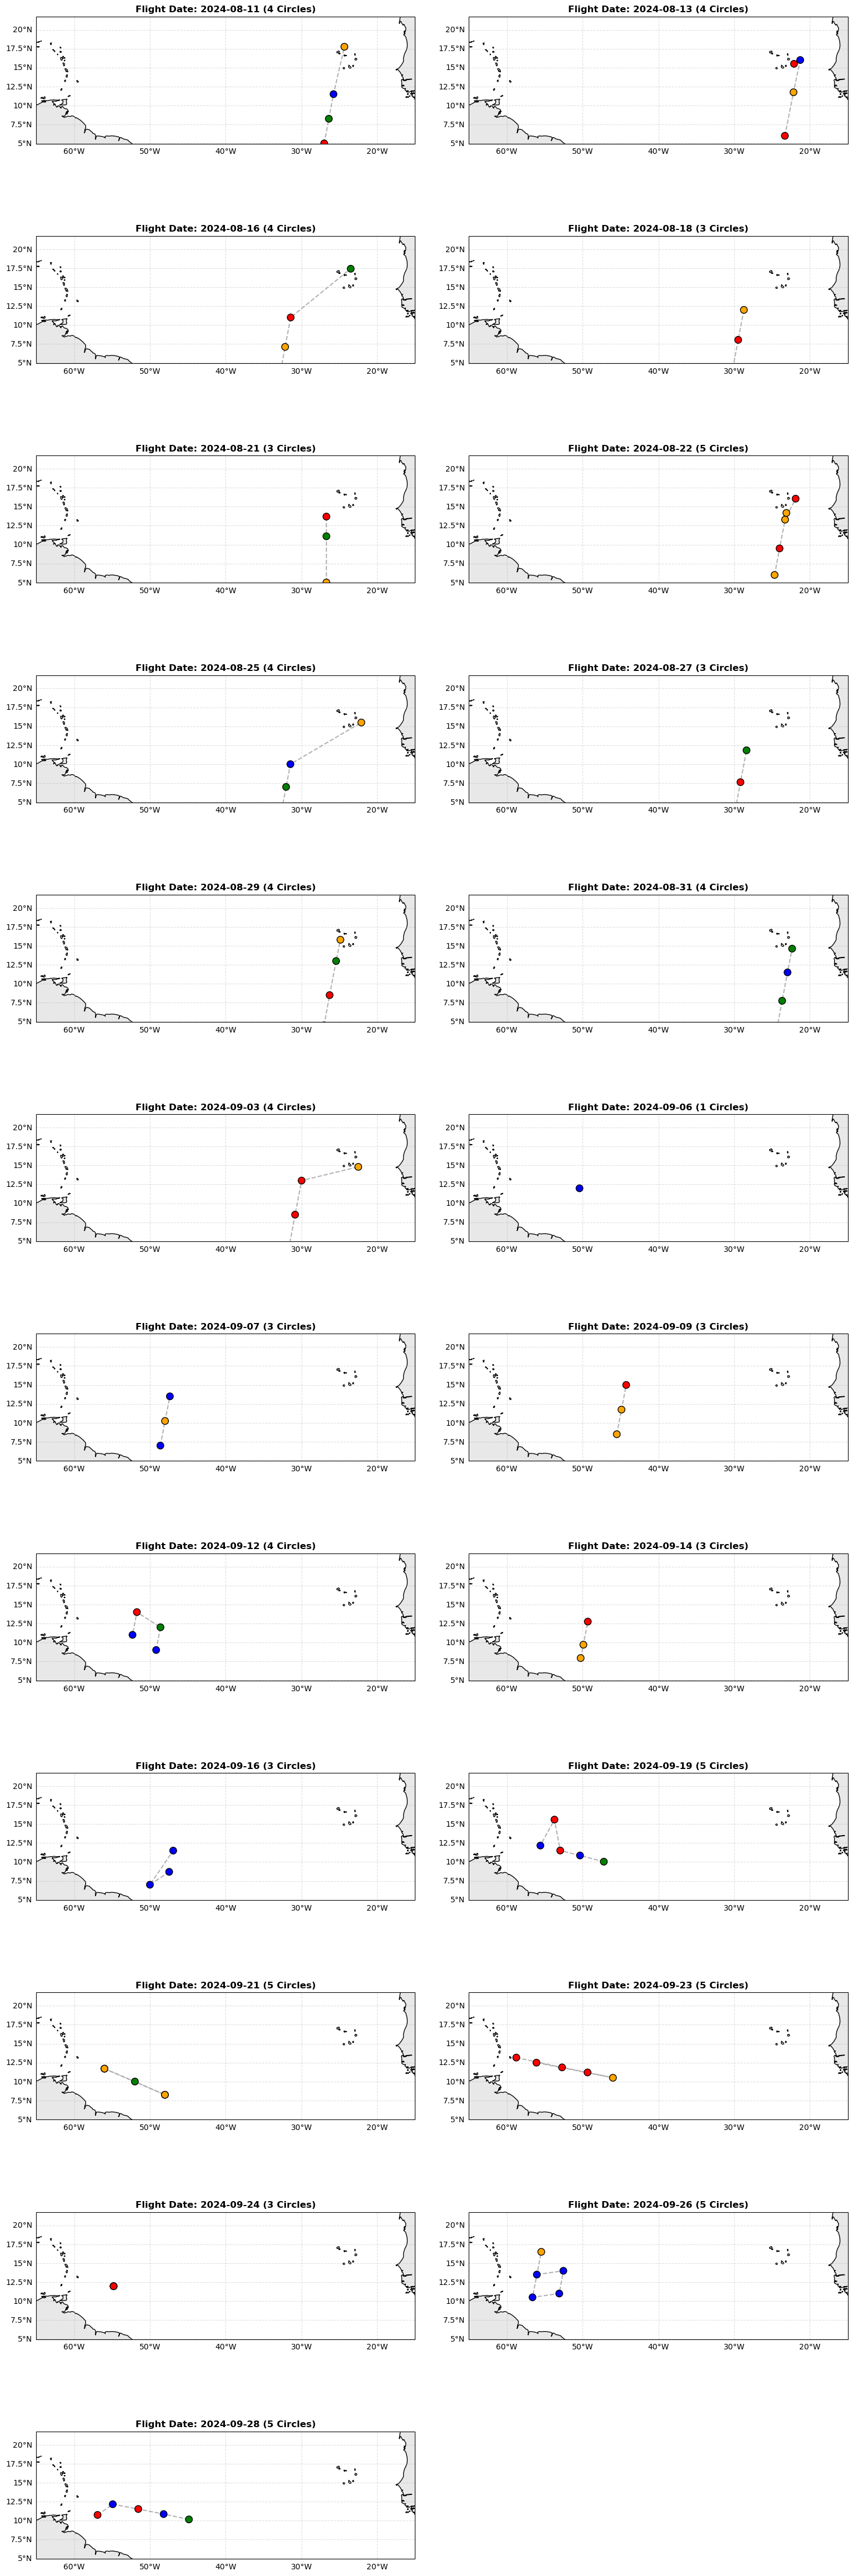

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math

# 1. SETUP DATA AND COLORS
regime_mapping = {
    'Top-Heavy (Deep)': 'red',
    'Bottom-Heavy (Congestus)': 'orange',
    'Shallow': 'green',
    'Suppressed / Weak': 'blue'
}

# Extract all valid data into a clean Pandas DataFrame for easy mapping
map_data = []
for c in ds_categorized.circle.values:
    cat = str(ds_categorized.category.sel(circle=c).values)
    if cat == "Missing Data":
        continue
        
    lat = ds_categorized['circle_lat'].sel(circle=c).values
    lon = ds_categorized['circle_lon'].sel(circle=c).values
    raw_time = ds_categorized['circle_time'].sel(circle=c).values
    
    dt = pd.to_datetime(raw_time)
    
    map_data.append({
        'circle_id': c,
        'lat': lat,
        'lon': lon,
        'datetime': dt,
        'date': dt.date(), # Extract just the date for grouping
        'category': cat,
        'color': regime_mapping[cat]
    })

df_map = pd.DataFrame(map_data)
unique_dates = sorted(df_map['date'].unique())

# Set geographic boundaries (Tropical Atlantic)
lon_min, lon_max = -65, -15
lat_min, lat_max = 5, 20

# ---------------------------------------------------------
# PART 1: THE MASTER COMBINED MAP (ALL DATES)
# ---------------------------------------------------------
fig_master = plt.figure(figsize=(12, 6))
ax_master = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax_master.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax_master.add_feature(cfeature.BORDERS, linestyle=':')
ax_master.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax_master.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add gridlines
gl = ax_master.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot all points
for cat, color in regime_mapping.items():
    subset = df_map[df_map['category'] == cat]
    ax_master.scatter(subset['lon'], subset['lat'], c=color, s=100, 
                      edgecolor='black', label=cat, transform=ccrs.PlateCarree(), zorder=5)

ax_master.legend(loc='upper right', title="Convective Regimes")
ax_master.set_title('Combined Spatial Distribution of All ORCESTRA Flight Circles', fontsize=16, fontweight='bold', pad=20)
plt.show()

# ---------------------------------------------------------
# PART 2: INDIVIDUAL MAPS FOR EACH DATE
# ---------------------------------------------------------
print("\n" + "="*60)
print("GENERATING INDIVIDUAL DAILY FLIGHT MAPS")
print("="*60 + "\n")

# Calculate grid size for subplots based on number of unique flight days
cols = 2
rows = math.ceil(len(unique_dates) / cols)

fig_daily = plt.figure(figsize=(cols*8, rows*4))

for i, date in enumerate(unique_dates):
    # Create subplot with map projection
    ax = fig_daily.add_subplot(rows, cols, i+1, projection=ccrs.PlateCarree())
    
    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False
    
    # Filter data for this specific day
    day_data = df_map[df_map['date'] == date]
    
    # Plot points for this day
    ax.scatter(day_data['lon'], day_data['lat'], c=day_data['color'], s=80, 
               edgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    
    # Add a dashed line connecting the circles in chronological order to show flight path
    day_data_sorted = day_data.sort_values('datetime')
    ax.plot(day_data_sorted['lon'], day_data_sorted['lat'], color='gray', 
            linestyle='--', alpha=0.6, transform=ccrs.PlateCarree(), zorder=4)
    
    ax.set_title(f'Flight Date: {date} ({len(day_data)} Circles)', fontsize=12, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from IPython.display import display

# Regime mapping for colors
regime_mapping = {
    'Top-Heavy (Deep)': 'red',
    'Bottom-Heavy (Congestus)': 'orange',
    'Shallow': 'green',
    'Suppressed / Weak': 'blue'
}

# Extract data into DataFrame 
map_data = []
for c in ds_categorized.circle.values:
    cat = str(ds_categorized.category.sel(circle=c).values)
    if cat == "Missing Data":
        continue
        
    raw_time = ds_categorized['circle_time'].sel(circle=c).values
    dt = pd.to_datetime(raw_time)
    
    map_data.append({
        'circle_id': c,
        'datetime': dt,
        'date': dt.date(),
        'category': cat,
        'color': regime_mapping[cat]
    })

df_map = pd.DataFrame(map_data)
unique_dates = sorted(df_map['date'].unique())

# Define axes limits
x_limits = (-1.0, 0.5)
y_limits = (1000, 100)

# Initialize totals
grand_totals = {cat: 0 for cat in regime_mapping.keys()}
total_all_circles = 0

# ---------------------------------------------------------
# 1. CREATE AND DISPLAY THE PANDAS SUMMARY TABLE
# ---------------------------------------------------------
summary_rows = []
for date in unique_dates:
    day_circles = df_map[df_map['date'] == date]
    
    # Initialize the row with the date
    row_data = {'Date': date}
    
    daily_total = 0
    # Fill in the circle IDs for each category
    for cat in regime_mapping.keys():
        cat_circles = day_circles[day_circles['category'] == cat]['circle_id'].tolist()
        count = len(cat_circles)
        if cat_circles:
            row_data[cat] = f"c{','.join(map(str, sorted(cat_circles)))}"
        else:
            row_data[cat] = "-" # Put a dash if there were no circles of this type
        
        daily_total += count
        grand_totals[cat] += count
        
    # Add the daily total column
    row_data['Total per Day'] = daily_total
    total_all_circles += daily_total
            
    summary_rows.append(row_data)
    
# Add the GRAND TOTAL row at the very bottom
grand_total_row = {'Date': 'GRAND TOTAL'}
for cat in regime_mapping.keys():
    grand_total_row[cat] = f"{grand_totals[cat]} circles"
grand_total_row['Total per Day'] = f"{total_all_circles} circles"

summary_rows.append(grand_total_row)

# Convert to Pandas DataFrame and set the Date as the index
summary_df = pd.DataFrame(summary_rows)
summary_df.set_index('Date', inplace=True)

print("Daily Categorization Summary:")
# display() forces Jupyter to render the Pandas DataFrame as a clean HTML table
display(summary_df) 

# ---------------------------------------------------------
# 2. CREATE THE 4-COLUMN PLOT COLLAGE
# ---------------------------------------------------------
cols = 4
rows = math.ceil(len(unique_dates) / cols)

# Adjusted figsize so the 4 columns fit nicely
fig = plt.figure(figsize=(cols * 4.5, rows * 5)) 

for i, date in enumerate(unique_dates):
    ax = fig.add_subplot(rows, cols, i+1)
    
    day_circles = df_map[df_map['date'] == date]
    
    # Plot each profile colored by category
    plotted_cats = set()
    for _, row in day_circles.iterrows():
        c = row['circle_id']
        cat = row['category']
        color = row['color']
        
        profile = ds_categorized['omega'].sel(circle=c)
        pressure = ds_categorized['p_mean'].sel(circle=c) / 100
        
        label = cat if cat not in plotted_cats else None
        ax.plot(profile, pressure, color=color, linewidth=2, label=label)
        plotted_cats.add(cat)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_xlabel('Omega (Pa/s)', fontsize=10)
    
    # Only show the Y-axis label on the far left column to avoid clutter
    if i % cols == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=10)
        
    ax.set_title(f'{date}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Optional: adjust legend size so it doesn't block the lines
    ax.legend(loc='upper right', fontsize=8) 

fig.suptitle('Daily Omega Profiles Across the ORCESTRA Campaign', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

Daily Categorization Summary:


,Top-Heavy (Deep),Bottom-Heavy (Congestus),Shallow,Suppressed / Weak,Total per Day
Date,,,,,
2024-08-11,c0,c3,c1,c2,4
2024-08-13,"c4,7",c5,-,c6,4
2024-08-16,"c8,10",c9,c11,-,4
2024-08-18,"c13,14",c12,-,-,3
2024-08-21,c17,c15,c16,-,3
2024-08-22,"c19,22","c18,20,21",-,-,5
2024-08-25,c23,c26,c24,c25,4
2024-08-27,c28,-,c29,c27,3
2024-08-29,c32,"c31,34",c33,-,4
